<a href="https://colab.research.google.com/github/jocelynbrownie27-max/Cholesterol-Project/blob/main/DSRP_2026_Jocelyn_Browne_(CHOLESTEROL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [131]:
import pandas as pd
df = pd.read_csv('/content/NCD_RisC_Nature_2020_Cholesterol_age_standardised_countries.csv')
df

,Country/Region/World,ISO,Sex,Year,Mean total cholesterol (mmol/L),Mean total cholesterol lower 95% uncertainty interval (mmol/L),Mean total cholesterol upper 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),Mean HDL cholesterol (mmol/L),Mean HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)
0,Afghanistan,AFG,Men,1980,4.263545,3.539636,4.959936,2.919134,2.486837,3.339214,1.221839,0.926460,1.497237
1,Afghanistan,AFG,Men,1981,4.266327,3.569655,4.931141,2.934723,2.512884,3.344176,1.214738,0.932500,1.476955
2,Afghanistan,AFG,Men,1982,4.269252,3.612601,4.904159,2.950451,2.543536,3.345615,1.207716,0.935305,1.462378
3,Afghanistan,AFG,Men,1983,4.272437,3.646602,4.881011,2.966397,2.570361,3.353339,1.200752,0.943039,1.444552
4,Afghanistan,AFG,Men,1984,4.275822,3.673783,4.866126,2.982507,2.598309,3.360546,1.193839,0.947619,1.427836
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15595,Zimbabwe,ZWE,Women,2014,4.161298,3.755729,4.588048,2.945255,2.711719,3.174748,1.312036,1.140103,1.483028
15596,Zimbabwe,ZWE,Women,2015,4.157357,3.710967,4.625261,2.945829,2.704246,3.184318,1.310691,1.126460,1.491962
15597,Zimbabwe,ZWE,Women,2016,4.153718,3.661819,4.663383,2.946790,2.694693,3.195830,1.309282,1.110321,1.504699
15598,Zimbabwe,ZWE,Women,2017,4.150368,3.608575,4.709977,2.948084,2.683316,3.207449,1.307992,1.093114,1.517367


cholesterol measured in mmol/L

#Cleaning Data

In [132]:
df.isna().sum()

,0
Country/Region/World,0
ISO,0
Sex,0
Year,0
Mean total cholesterol (mmol/L),0
Mean total cholesterol lower 95% uncertainty interval (mmol/L),0
Mean total cholesterol upper 95% uncertainty interval (mmol/L),0
Mean non-HDL cholesterol (mmol/L),0
Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),0
Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),0


In [133]:
df.duplicated().sum()

np.int64(0)

No duplicated or null values

In [134]:
df.value_counts(['Country/Region/World'])

,count
Country/Region/World,
Afghanistan,78
Albania,78
Algeria,78
American Samoa,78
Andorra,78
...,...
Venezuela,78
Viet Nam,78
Yemen,78


78 total observations for each country, 39 men, 39 women

In [135]:
df.drop(columns=['ISO'], inplace=True)

removed ISO column as I feel I wouldn't need it

In [136]:
df.shape

(15600, 12)

In [137]:
df.columns

Index(['Country/Region/World', 'Sex', 'Year',
       'Mean total cholesterol (mmol/L)',
       'Mean total cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean total cholesterol upper 95% uncertainty interval (mmol/L)',
       'Mean non-HDL cholesterol (mmol/L)',
       'Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L)',
       'Mean HDL cholesterol (mmol/L)',
       'Mean HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)'],
      dtype='object')

In [138]:
df['Country/Region/World'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'China (Hong Kong SAR)', 'Colombia', 'Comoros', 'Congo',
       'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
       'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'DR Congo', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Ethiopia', 'Fiji', 'Finland', 'France', 'French Polynesia',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Gh

In [139]:
df.drop(columns=['Mean total cholesterol lower 95% uncertainty interval (mmol/L)','Mean total cholesterol upper 95% uncertainty interval (mmol/L)','Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L)','Mean HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)'], inplace=True)
df

,Country/Region/World,Sex,Year,Mean total cholesterol (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean HDL cholesterol (mmol/L)
0,Afghanistan,Men,1980,4.263545,2.919134,1.221839
1,Afghanistan,Men,1981,4.266327,2.934723,1.214738
2,Afghanistan,Men,1982,4.269252,2.950451,1.207716
3,Afghanistan,Men,1983,4.272437,2.966397,1.200752
4,Afghanistan,Men,1984,4.275822,2.982507,1.193839
...,...,...,...,...,...,...
15595,Zimbabwe,Women,2014,4.161298,2.945255,1.312036
15596,Zimbabwe,Women,2015,4.157357,2.945829,1.310691
15597,Zimbabwe,Women,2016,4.153718,2.946790,1.309282
15598,Zimbabwe,Women,2017,4.150368,2.948084,1.307992


# Creating Visuals
---



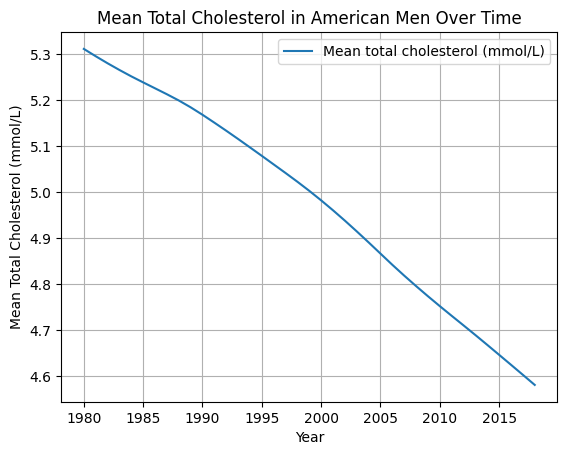

In [140]:
import matplotlib.pyplot as plt

specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Men')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean total cholesterol (mmol/L)", kind="line", title="Mean Total Cholesterol in American Men Over Time", xlabel="Year", ylabel="Mean Total Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

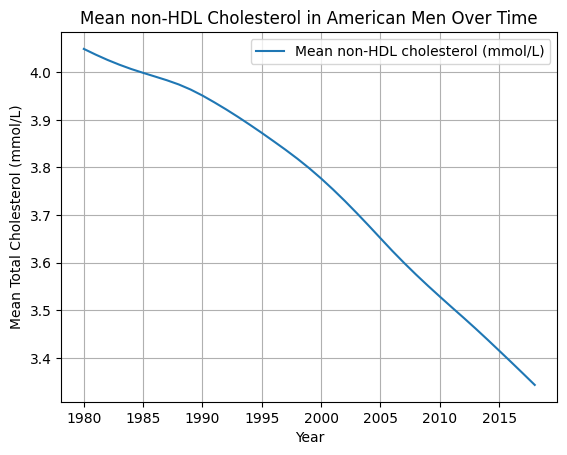

In [141]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Men')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in American Men Over Time", xlabel="Year", ylabel="Mean Total Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

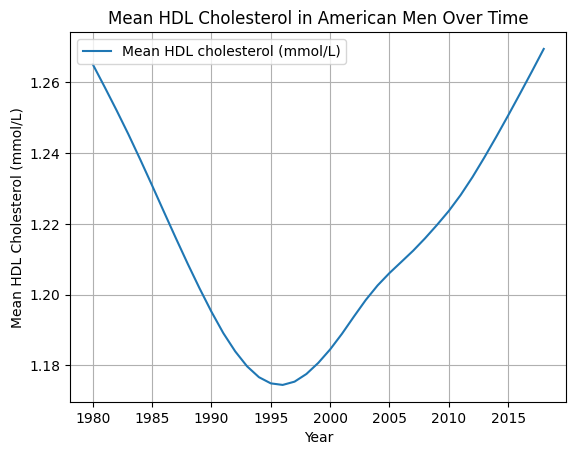

In [142]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Men')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean HDL cholesterol (mmol/L)", kind="line", title="Mean HDL Cholesterol in American Men Over Time", xlabel="Year", ylabel="Mean HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

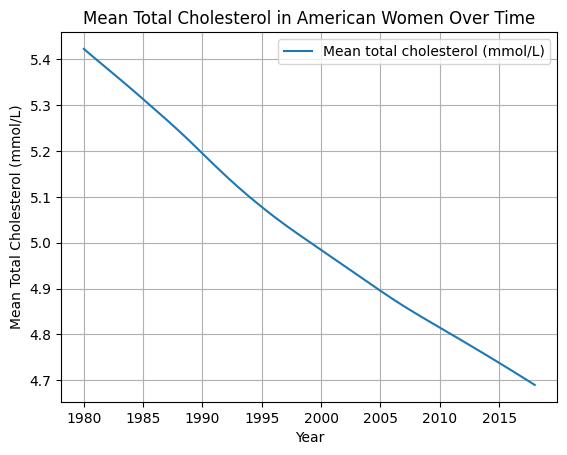

In [143]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean total cholesterol (mmol/L)", kind="line", title="Mean Total Cholesterol in American Women Over Time", xlabel="Year", ylabel="Mean Total Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

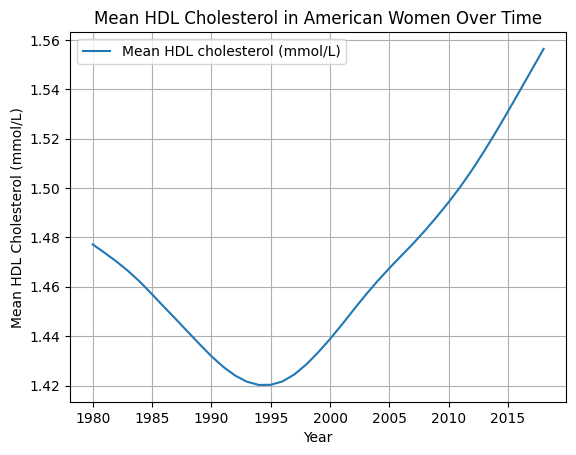

In [144]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean HDL cholesterol (mmol/L)", kind="line", title="Mean HDL Cholesterol in American Women Over Time", xlabel="Year", ylabel="Mean HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

# Non-HDL Cholesterol Levels for Women (LINEPLOTS)

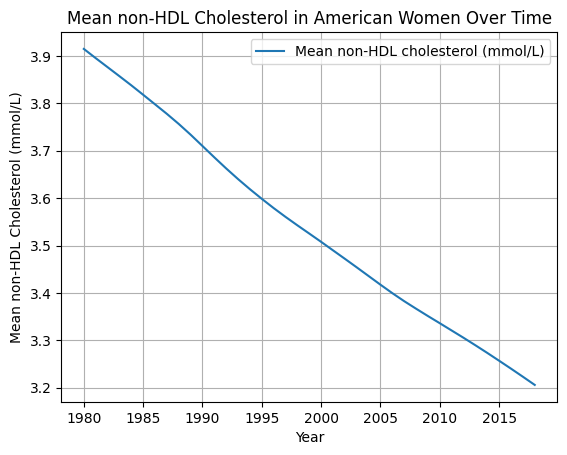

In [145]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in American Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

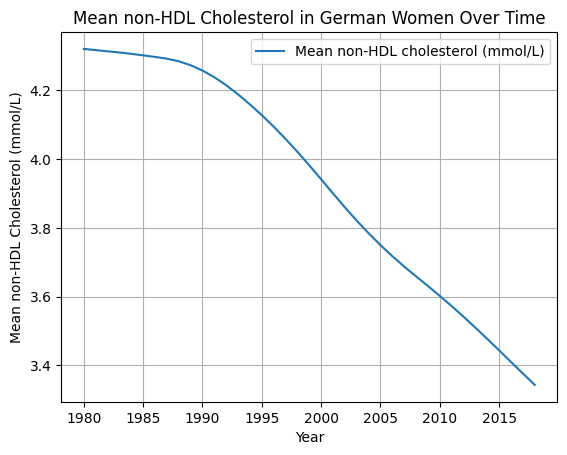

In [146]:
specific_country_df = df[(df['Country/Region/World'] == 'Germany') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in German Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

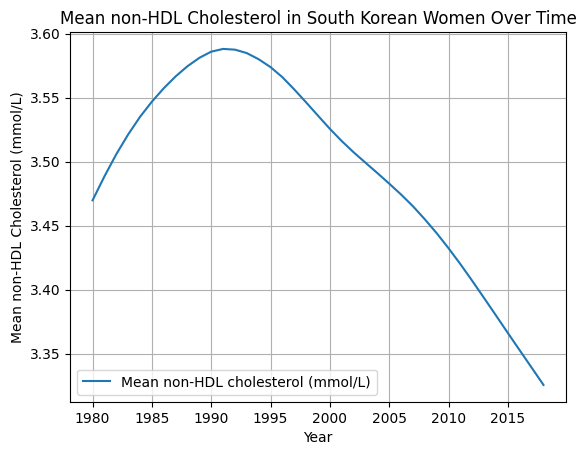

In [147]:
specific_country_df = df[(df['Country/Region/World'] == 'South Korea') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in South Korean Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

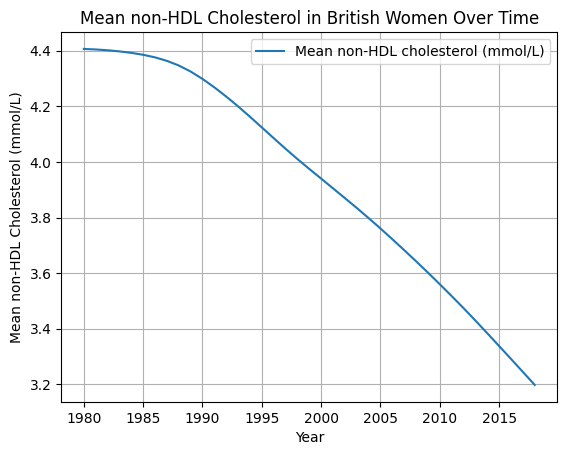

In [148]:
specific_country_df = df[(df['Country/Region/World'] == 'United Kingdom') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in British Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

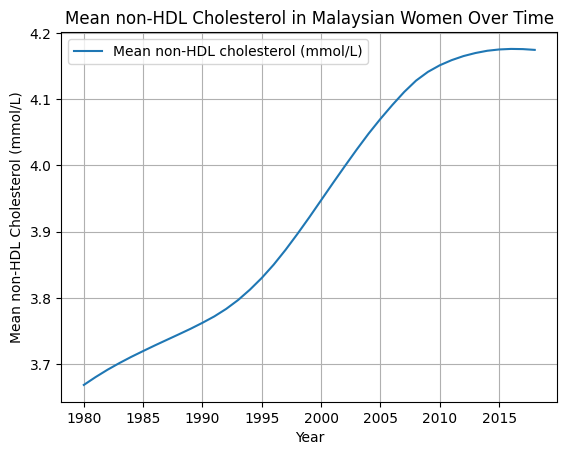

In [149]:
specific_country_df = df[(df['Country/Region/World'] == 'Malaysia') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Malaysian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

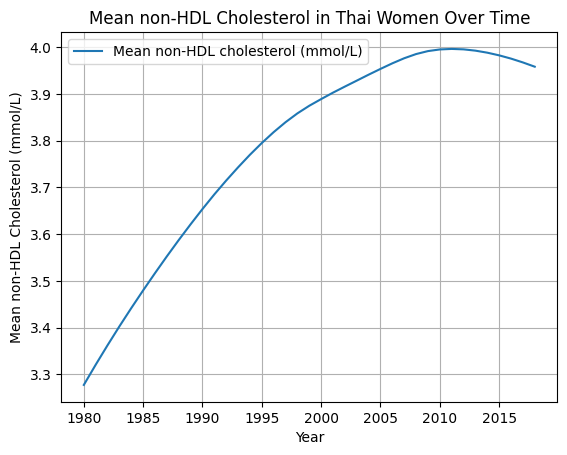

In [150]:
specific_country_df = df[(df['Country/Region/World'] == 'Thailand') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Thai Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

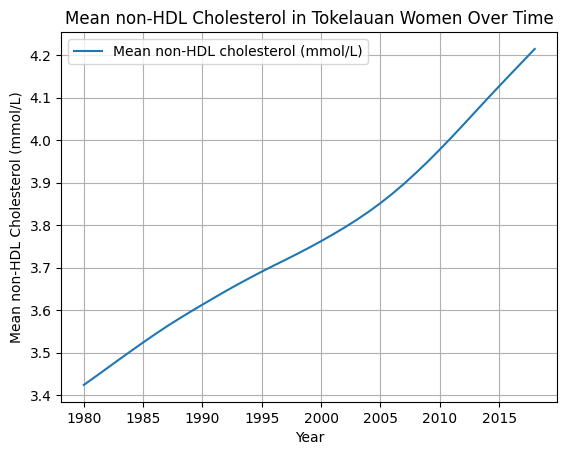

In [151]:
specific_country_df = df[(df['Country/Region/World'] == 'Tokelau') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Tokelauan Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

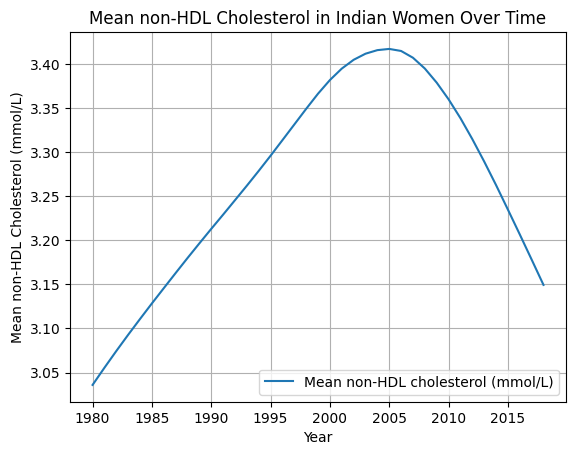

In [152]:
specific_country_df = df[(df['Country/Region/World'] == 'India') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Indian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

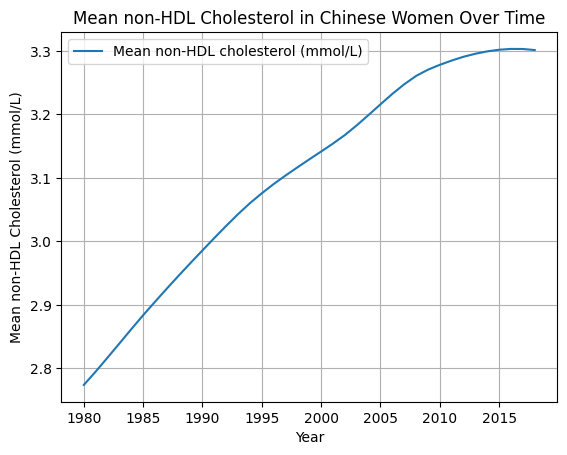

In [153]:
specific_country_df = df[(df['Country/Region/World'] == 'China') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Chinese Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

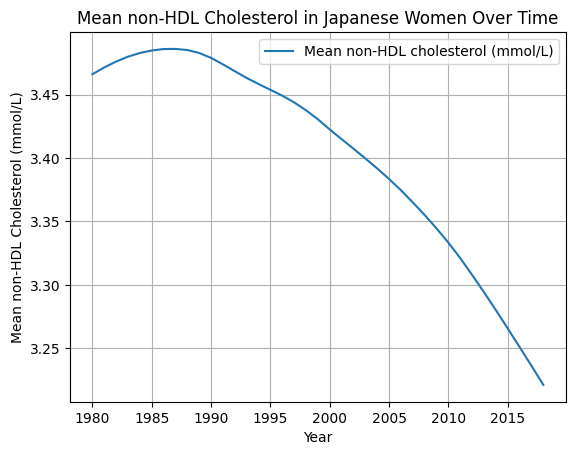

In [154]:
specific_country_df = df[(df['Country/Region/World'] == 'Japan') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Japanese Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

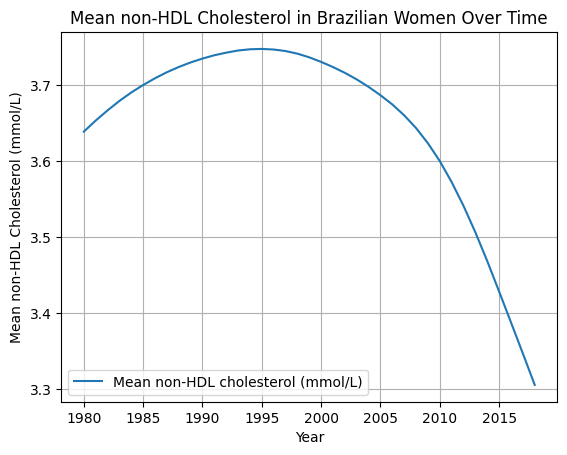

In [155]:
specific_country_df = df[(df['Country/Region/World'] == 'Brazil') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Brazilian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

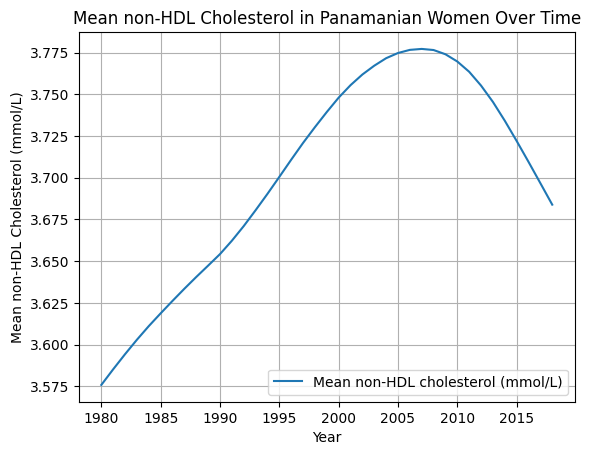

In [156]:
specific_country_df = df[(df['Country/Region/World'] == 'Panama') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Panamanian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

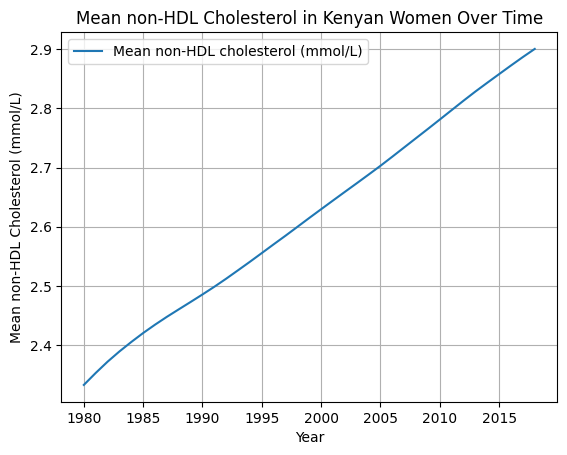

In [157]:
specific_country_df = df[(df['Country/Region/World'] == 'Kenya') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Kenyan Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

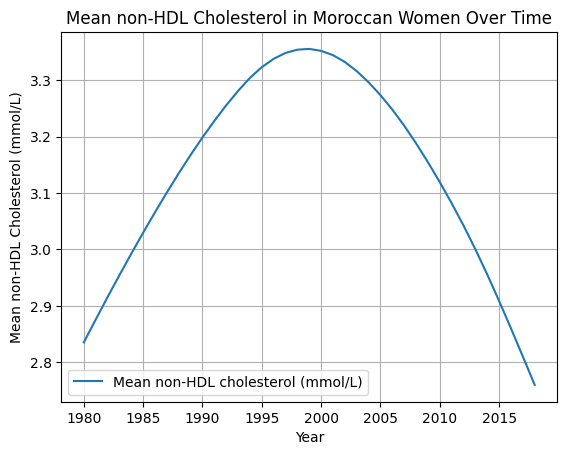

In [158]:
specific_country_df = df[(df['Country/Region/World'] == 'Morocco') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Moroccan Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

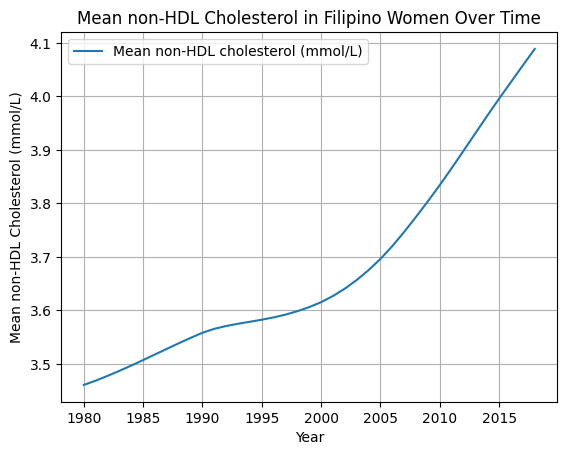

In [159]:
specific_country_df = df[(df['Country/Region/World'] == 'Philippines') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Filipino Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

# Comparing non-HDL cholesterol in women by country (BARPLOTS)

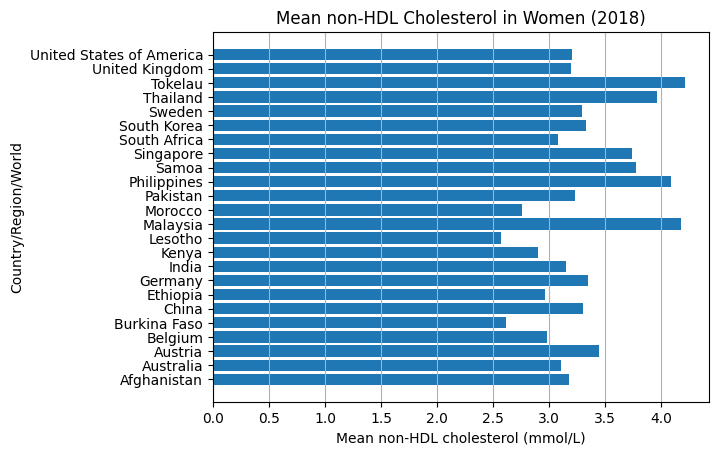

In [160]:
selected_countries = ['Australia', 'Austria', 'United States of America', 'United Kingdom', 'Germany', 'Malaysia', 'Thailand', 'China', 'Kenya', 'Morocco', 'South Africa', 'Ethiopia', 'Tokelau', 'Afghanistan', 'India', 'Pakistan', 'South Korea', 'Philippines', 'Belgium', 'Sweden', 'Singapore', 'Burkina Faso', 'Lesotho', 'Samoa']
specific_country_df = df[(df['Year'] == 2018) & (df['Sex'] == 'Women') & (df['Country/Region/World'].isin(selected_countries))].copy()
plt.barh(specific_country_df['Country/Region/World'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'])
plt.title('Mean non-HDL Cholesterol in Women (2018)')
plt.xlabel('Mean non-HDL cholesterol (mmol/L)')
plt.ylabel('Country/Region/World')
plt.grid(axis='x')
plt.show()

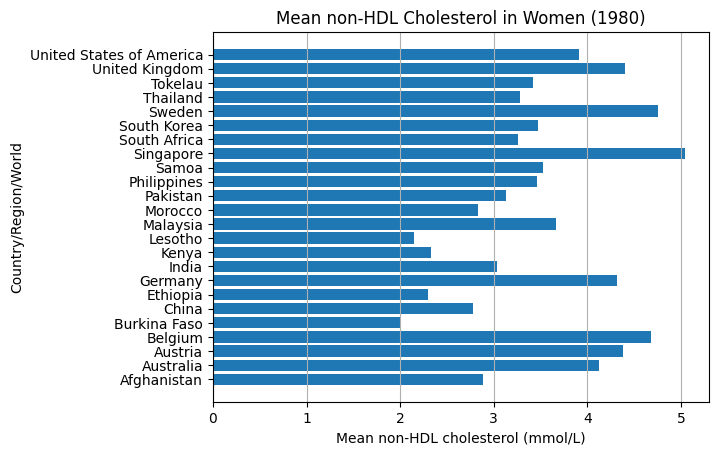

In [161]:
selected_countries = ['Australia', 'Austria', 'United States of America', 'United Kingdom', 'Germany', 'Malaysia', 'Thailand', 'China', 'Kenya', 'Morocco', 'South Africa', 'Ethiopia', 'Tokelau', 'Afghanistan', 'India', 'Pakistan', 'South Korea', 'Philippines', 'Belgium', 'Sweden', 'Singapore', 'Burkina Faso', 'Lesotho', 'Samoa']
specific_country_df = df[(df['Year'] == 1980) & (df['Sex'] == 'Women') & (df['Country/Region/World'].isin(selected_countries))].copy()
plt.barh(specific_country_df['Country/Region/World'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'])
plt.title('Mean non-HDL Cholesterol in Women (1980)')
plt.xlabel('Mean non-HDL cholesterol (mmol/L)')
plt.ylabel('Country/Region/World')
plt.grid(axis='x')
plt.show()

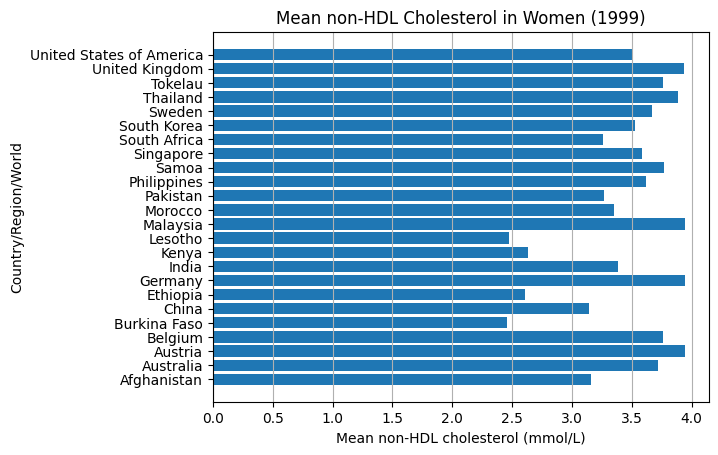

In [162]:
selected_countries = ['Australia', 'Austria', 'United States of America', 'United Kingdom', 'Germany', 'Malaysia', 'Thailand', 'China', 'Kenya', 'Morocco', 'South Africa', 'Ethiopia', 'Tokelau', 'Afghanistan', 'India', 'Pakistan', 'South Korea', 'Philippines', 'Belgium', 'Sweden', 'Singapore', 'Burkina Faso', 'Lesotho', 'Samoa']
specific_country_df = df[(df['Year'] == 2000) & (df['Sex'] == 'Women') & (df['Country/Region/World'].isin(selected_countries))].copy()
plt.barh(specific_country_df['Country/Region/World'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'])
plt.title('Mean non-HDL Cholesterol in Women (1999)')
plt.xlabel('Mean non-HDL cholesterol (mmol/L)')
plt.ylabel('Country/Region/World')
plt.grid(axis='x')
plt.show()

# Averages, Minimums, And Maximums for non-HDL cholesterol in women from around the world

In [163]:
df[(df['Year']==1980) & (df['Sex']=='Women')]['Mean non-HDL cholesterol (mmol/L)'].describe()

,Mean non-HDL cholesterol (mmol/L)
count,200.000000
mean,3.415461
std,0.694330
min,1.998707
25%,2.834562
50%,3.437201
75%,3.910718
max,5.045263


In [164]:
max_row = df.loc[df[(df['Year']==1980) & (df['Sex']=='Women')]['Mean non-HDL cholesterol (mmol/L)'].idxmax()]
print(max_row)

Country/Region/World                 Singapore
Sex                                      Women
Year                                      1980
Mean total cholesterol (mmol/L)       5.653252
Mean non-HDL cholesterol (mmol/L)     5.045263
Mean HDL cholesterol (mmol/L)         1.132706
Name: 14001, dtype: object


In [165]:
min_row = df.loc[df[(df['Year']==1980) & (df['Sex']=='Women')]['Mean non-HDL cholesterol (mmol/L)'].idxmin()]
print(min_row)

Country/Region/World                 Burkina Faso
Sex                                         Women
Year                                         1980
Mean total cholesterol (mmol/L)          3.598718
Mean non-HDL cholesterol (mmol/L)        1.998707
Mean HDL cholesterol (mmol/L)            1.056218
Name: 8892, dtype: object


In [166]:
df[(df['Year']==1999) & (df['Sex']=='Women')]['Mean non-HDL cholesterol (mmol/L)'].describe()

,Mean non-HDL cholesterol (mmol/L)
count,200.000000
mean,3.431253
std,0.462768
min,2.215427
25%,3.079998
50%,3.521506
75%,3.809403
max,4.267119


In [167]:
df[(df['Year']==2018) & (df['Sex']=='Women')]['Mean non-HDL cholesterol (mmol/L)'].describe()

,Mean non-HDL cholesterol (mmol/L)
count,200.000000
mean,3.313296
std,0.307772
min,2.575007
25%,3.079996
50%,3.340948
75%,3.537832
max,4.214999


In [168]:
max_row = df.loc[df[(df['Year']==2018) & (df['Sex']=='Women')]['Mean non-HDL cholesterol (mmol/L)'].idxmax()]
print(max_row)

Country/Region/World                  Tokelau
Sex                                     Women
Year                                     2018
Mean total cholesterol (mmol/L)      4.869568
Mean non-HDL cholesterol (mmol/L)    4.214999
Mean HDL cholesterol (mmol/L)        1.031738
Name: 14858, dtype: object


In [169]:
min_row = df.loc[df[(df['Year']==2018) & (df['Sex']=='Women')]['Mean non-HDL cholesterol (mmol/L)'].idxmin()]
print(min_row)

Country/Region/World                  Lesotho
Sex                                     Women
Year                                     2018
Mean total cholesterol (mmol/L)      3.896104
Mean non-HDL cholesterol (mmol/L)    2.575007
Mean HDL cholesterol (mmol/L)        1.194827
Name: 11699, dtype: object


# Comparisons Through Line Plots

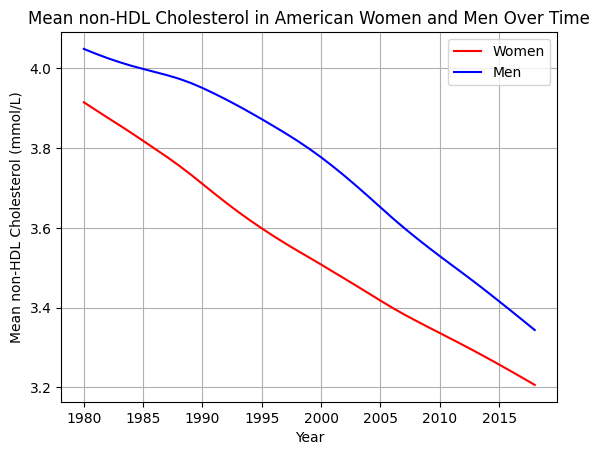

In [170]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
second_line = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Men')].copy()
#specific_country_df = specific_country_df.sort_values("Year")
#second_line = second_line.sort_values("Year")
#specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", label="Women", color="red")
#second_line.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", label="Men", color="blue")
plt.plot(specific_country_df['Year'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'], label="Women", color='red')
plt.plot(second_line['Year'], second_line['Mean non-HDL cholesterol (mmol/L)'], label="Men", color='blue')
plt.legend()
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Mean non-HDL Cholesterol (mmol/L)')
plt.title('Mean non-HDL Cholesterol in American Women and Men Over Time')
plt.show()

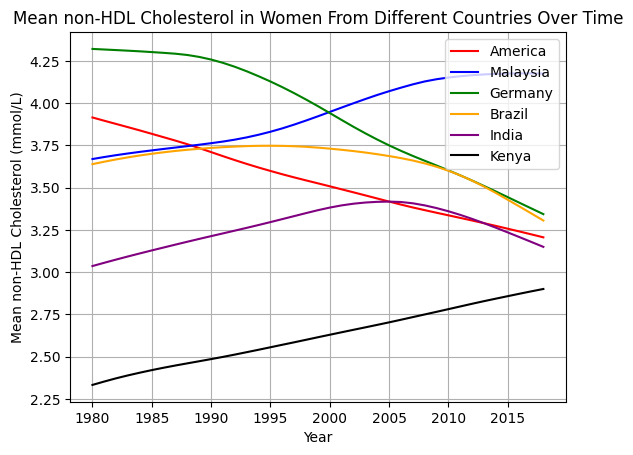

In [171]:
first_line = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
second_line = df[(df['Country/Region/World'] == 'Malaysia') & (df['Sex'] == 'Women')].copy()
third_line = df[(df['Country/Region/World'] == 'Germany') & (df['Sex'] == 'Women')].copy()
fourth_line = df[(df['Country/Region/World'] == 'Brazil') & (df['Sex'] == 'Women')].copy()
fifth_line = df[(df['Country/Region/World'] == 'India') & (df['Sex'] == 'Women')].copy()
sixth_line = df[(df['Country/Region/World'] == 'Kenya') & (df['Sex'] == 'Women')].copy()

plt.plot(specific_country_df['Year'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'], label="America", color='red')
plt.plot(second_line['Year'], second_line['Mean non-HDL cholesterol (mmol/L)'], label="Malaysia", color='blue')
plt.plot(third_line['Year'], third_line['Mean non-HDL cholesterol (mmol/L)'], label="Germany", color='green')
plt.plot(fourth_line['Year'], fourth_line['Mean non-HDL cholesterol (mmol/L)'], label="Brazil", color='orange')
plt.plot(fifth_line['Year'], fifth_line['Mean non-HDL cholesterol (mmol/L)'], label="India", color='purple')
plt.plot(sixth_line['Year'], sixth_line['Mean non-HDL cholesterol (mmol/L)'], label="Kenya", color='black')

plt.legend()
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Mean non-HDL Cholesterol (mmol/L)')
plt.title('Mean non-HDL Cholesterol in Women From Different Countries Over Time')
plt.show()

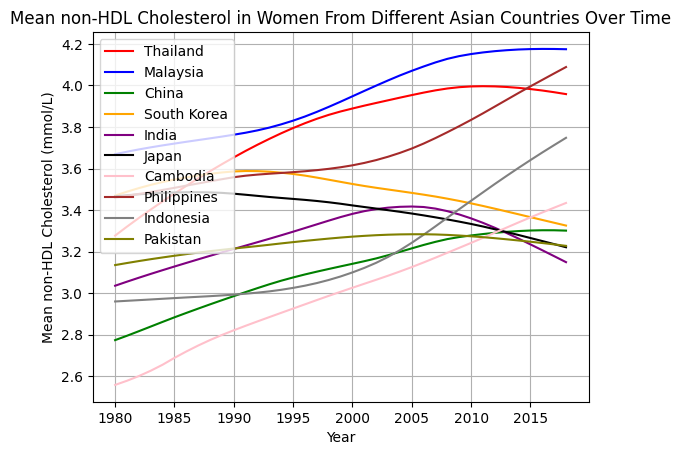

In [172]:
first_line = df[(df['Country/Region/World'] == 'Thailand') & (df['Sex'] == 'Women')].copy()
second_line = df[(df['Country/Region/World'] == 'Malaysia') & (df['Sex'] == 'Women')].copy()
third_line = df[(df['Country/Region/World'] == 'China') & (df['Sex'] == 'Women')].copy()
fourth_line = df[(df['Country/Region/World'] == 'South Korea') & (df['Sex'] == 'Women')].copy()
fifth_line = df[(df['Country/Region/World'] == 'India') & (df['Sex'] == 'Women')].copy()
sixth_line = df[(df['Country/Region/World'] == 'Japan') & (df['Sex'] == 'Women')].copy()
seventh_line = df[(df['Country/Region/World'] == 'Cambodia') & (df['Sex'] == 'Women')].copy()
eighth_line = df[(df['Country/Region/World'] == 'Philippines') & (df['Sex'] == 'Women')].copy()
ninth_line = df[(df['Country/Region/World'] == 'Indonesia') & (df['Sex'] == 'Women')].copy()
tenth_line = df[(df['Country/Region/World'] == 'Pakistan') & (df['Sex'] == 'Women')].copy()

plt.plot(specific_country_df['Year'], first_line['Mean non-HDL cholesterol (mmol/L)'], label="Thailand", color='red')
plt.plot(second_line['Year'], second_line['Mean non-HDL cholesterol (mmol/L)'], label="Malaysia", color='blue')
plt.plot(third_line['Year'], third_line['Mean non-HDL cholesterol (mmol/L)'], label="China", color='green')
plt.plot(fourth_line['Year'], fourth_line['Mean non-HDL cholesterol (mmol/L)'], label="South Korea", color='orange')
plt.plot(fifth_line['Year'], fifth_line['Mean non-HDL cholesterol (mmol/L)'], label="India", color='purple')
plt.plot(sixth_line['Year'], sixth_line['Mean non-HDL cholesterol (mmol/L)'], label="Japan", color='black')
plt.plot(seventh_line['Year'], seventh_line['Mean non-HDL cholesterol (mmol/L)'], label="Cambodia", color='pink')
plt.plot(eighth_line['Year'], eighth_line['Mean non-HDL cholesterol (mmol/L)'], label="Philippines", color='brown')
plt.plot(ninth_line['Year'], ninth_line['Mean non-HDL cholesterol (mmol/L)'], label="Indonesia", color='gray')
plt.plot(tenth_line['Year'], tenth_line['Mean non-HDL cholesterol (mmol/L)'], label="Pakistan", color='olive')

plt.legend()
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Mean non-HDL Cholesterol (mmol/L)')
plt.title('Mean non-HDL Cholesterol in Women From Different Asian Countries Over Time')
plt.show()

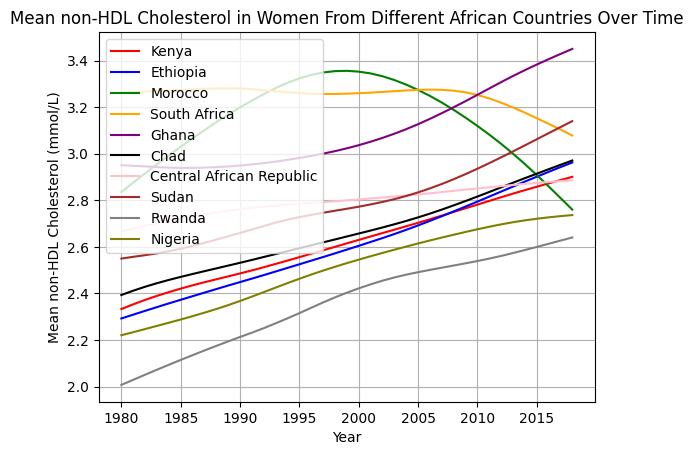

In [173]:
first_line = df[(df['Country/Region/World'] == 'Kenya') & (df['Sex'] == 'Women')].copy()
second_line = df[(df['Country/Region/World'] == 'Ethiopia') & (df['Sex'] == 'Women')].copy()
third_line = df[(df['Country/Region/World'] == 'Morocco') & (df['Sex'] == 'Women')].copy()
fourth_line = df[(df['Country/Region/World'] == 'South Africa') & (df['Sex'] == 'Women')].copy()
fifth_line = df[(df['Country/Region/World'] == 'Ghana') & (df['Sex'] == 'Women')].copy()
sixth_line = df[(df['Country/Region/World'] == 'Chad') & (df['Sex'] == 'Women')].copy()
seventh_line = df[(df['Country/Region/World'] == 'Central African Republic') & (df['Sex'] == 'Women')].copy()
eighth_line = df[(df['Country/Region/World'] == 'Sudan') & (df['Sex'] == 'Women')].copy()
ninth_line = df[(df['Country/Region/World'] == 'Rwanda') & (df['Sex'] == 'Women')].copy()
tenth_line = df[(df['Country/Region/World'] == 'Nigeria') & (df['Sex'] == 'Women')].copy()

plt.plot(specific_country_df['Year'], first_line['Mean non-HDL cholesterol (mmol/L)'], label="Kenya", color='red')
plt.plot(second_line['Year'], second_line['Mean non-HDL cholesterol (mmol/L)'], label="Ethiopia", color='blue')
plt.plot(third_line['Year'], third_line['Mean non-HDL cholesterol (mmol/L)'], label="Morocco", color='green')
plt.plot(fourth_line['Year'], fourth_line['Mean non-HDL cholesterol (mmol/L)'], label="South Africa", color='orange')
plt.plot(fifth_line['Year'], fifth_line['Mean non-HDL cholesterol (mmol/L)'], label="Ghana", color='purple')
plt.plot(sixth_line['Year'], sixth_line['Mean non-HDL cholesterol (mmol/L)'], label="Chad", color='black')
plt.plot(seventh_line['Year'], seventh_line['Mean non-HDL cholesterol (mmol/L)'], label="Central African Republic", color='pink')
plt.plot(eighth_line['Year'], eighth_line['Mean non-HDL cholesterol (mmol/L)'], label="Sudan", color='brown')
plt.plot(ninth_line['Year'], ninth_line['Mean non-HDL cholesterol (mmol/L)'], label="Rwanda", color='gray')
plt.plot(tenth_line['Year'], tenth_line['Mean non-HDL cholesterol (mmol/L)'], label="Nigeria", color='olive')

plt.legend()
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Mean non-HDL Cholesterol (mmol/L)')
plt.title('Mean non-HDL Cholesterol in Women From Different African Countries Over Time')
plt.show()

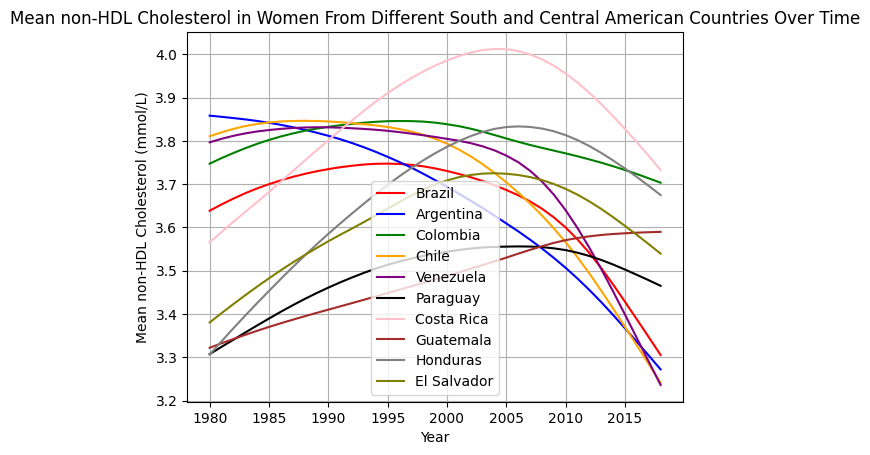

In [174]:
first_line = df[(df['Country/Region/World'] == 'Brazil') & (df['Sex'] == 'Women')].copy()
second_line = df[(df['Country/Region/World'] == 'Argentina') & (df['Sex'] == 'Women')].copy()
third_line = df[(df['Country/Region/World'] == 'Colombia') & (df['Sex'] == 'Women')].copy()
fourth_line = df[(df['Country/Region/World'] == 'Chile') & (df['Sex'] == 'Women')].copy()
fifth_line = df[(df['Country/Region/World'] == 'Venezuela') & (df['Sex'] == 'Women')].copy()
sixth_line = df[(df['Country/Region/World'] == 'Paraguay') & (df['Sex'] == 'Women')].copy()
seventh_line = df[(df['Country/Region/World'] == 'Costa Rica') & (df['Sex'] == 'Women')].copy()
eighth_line = df[(df['Country/Region/World'] == 'Guatemala') & (df['Sex'] == 'Women')].copy()
ninth_line = df[(df['Country/Region/World'] == 'Honduras') & (df['Sex'] == 'Women')].copy()
tenth_line = df[(df['Country/Region/World'] == 'El Salvador') & (df['Sex'] == 'Women')].copy()

plt.plot(specific_country_df['Year'], first_line['Mean non-HDL cholesterol (mmol/L)'], label="Brazil", color='red')
plt.plot(second_line['Year'], second_line['Mean non-HDL cholesterol (mmol/L)'], label="Argentina", color='blue')
plt.plot(third_line['Year'], third_line['Mean non-HDL cholesterol (mmol/L)'], label="Colombia", color='green')
plt.plot(fourth_line['Year'], fourth_line['Mean non-HDL cholesterol (mmol/L)'], label="Chile", color='orange')
plt.plot(fifth_line['Year'], fifth_line['Mean non-HDL cholesterol (mmol/L)'], label="Venezuela", color='purple')
plt.plot(sixth_line['Year'], sixth_line['Mean non-HDL cholesterol (mmol/L)'], label="Paraguay", color='black')
plt.plot(seventh_line['Year'], seventh_line['Mean non-HDL cholesterol (mmol/L)'], label="Costa Rica", color='pink')
plt.plot(eighth_line['Year'], eighth_line['Mean non-HDL cholesterol (mmol/L)'], label="Guatemala", color='brown')
plt.plot(ninth_line['Year'], ninth_line['Mean non-HDL cholesterol (mmol/L)'], label="Honduras", color='gray')
plt.plot(tenth_line['Year'], tenth_line['Mean non-HDL cholesterol (mmol/L)'], label="El Salvador", color='olive')

plt.legend()
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Mean non-HDL Cholesterol (mmol/L)')
plt.title('Mean non-HDL Cholesterol in Women From Different South and Central American Countries Over Time')
plt.show()

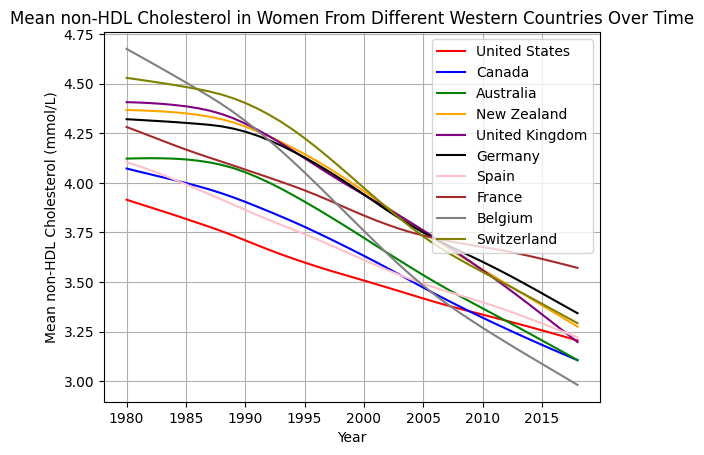

In [175]:
first_line = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
second_line = df[(df['Country/Region/World'] == 'Canada') & (df['Sex'] == 'Women')].copy()
third_line = df[(df['Country/Region/World'] == 'Australia') & (df['Sex'] == 'Women')].copy()
fourth_line = df[(df['Country/Region/World'] == 'New Zealand') & (df['Sex'] == 'Women')].copy()
fifth_line = df[(df['Country/Region/World'] == 'United Kingdom') & (df['Sex'] == 'Women')].copy()
sixth_line = df[(df['Country/Region/World'] == 'Germany') & (df['Sex'] == 'Women')].copy()
seventh_line = df[(df['Country/Region/World'] == 'Spain') & (df['Sex'] == 'Women')].copy()
eighth_line = df[(df['Country/Region/World'] == 'France') & (df['Sex'] == 'Women')].copy()
ninth_line = df[(df['Country/Region/World'] == 'Belgium') & (df['Sex'] == 'Women')].copy()
tenth_line = df[(df['Country/Region/World'] == 'Switzerland') & (df['Sex'] == 'Women')].copy()

plt.plot(specific_country_df['Year'], first_line['Mean non-HDL cholesterol (mmol/L)'], label="United States", color='red')
plt.plot(second_line['Year'], second_line['Mean non-HDL cholesterol (mmol/L)'], label="Canada", color='blue')
plt.plot(third_line['Year'], third_line['Mean non-HDL cholesterol (mmol/L)'], label="Australia", color='green')
plt.plot(fourth_line['Year'], fourth_line['Mean non-HDL cholesterol (mmol/L)'], label="New Zealand", color='orange')
plt.plot(fifth_line['Year'], fifth_line['Mean non-HDL cholesterol (mmol/L)'], label="United Kingdom", color='purple')
plt.plot(sixth_line['Year'], sixth_line['Mean non-HDL cholesterol (mmol/L)'], label="Germany", color='black')
plt.plot(seventh_line['Year'], seventh_line['Mean non-HDL cholesterol (mmol/L)'], label="Spain", color='pink')
plt.plot(eighth_line['Year'], eighth_line['Mean non-HDL cholesterol (mmol/L)'], label="France", color='brown')
plt.plot(ninth_line['Year'], ninth_line['Mean non-HDL cholesterol (mmol/L)'], label="Belgium", color='gray')
plt.plot(tenth_line['Year'], tenth_line['Mean non-HDL cholesterol (mmol/L)'], label="Switzerland", color='olive')

plt.legend()
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Mean non-HDL Cholesterol (mmol/L)')
plt.title('Mean non-HDL Cholesterol in Women From Different Western Countries Over Time')
plt.show()

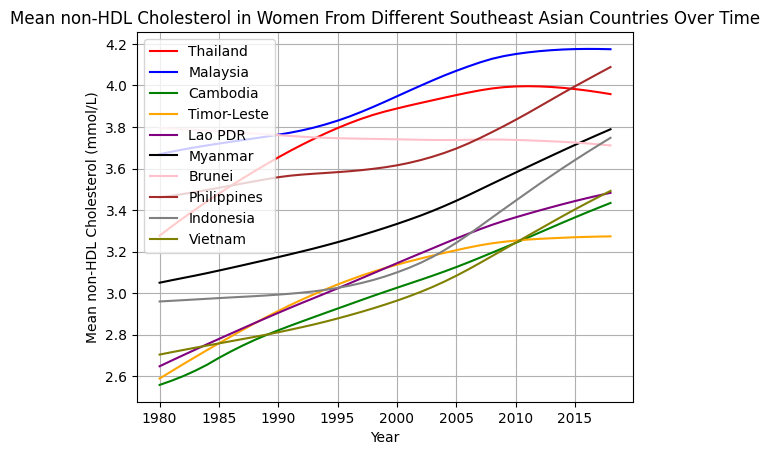

In [176]:
first_line = df[(df['Country/Region/World'] == 'Thailand') & (df['Sex'] == 'Women')].copy()
second_line = df[(df['Country/Region/World'] == 'Malaysia') & (df['Sex'] == 'Women')].copy()
third_line = df[(df['Country/Region/World'] == 'Cambodia') & (df['Sex'] == 'Women')].copy()
fourth_line = df[(df['Country/Region/World'] == 'Timor-Leste') & (df['Sex'] == 'Women')].copy()
fifth_line = df[(df['Country/Region/World'] == 'Lao PDR') & (df['Sex'] == 'Women')].copy()
sixth_line = df[(df['Country/Region/World'] == 'Myanmar') & (df['Sex'] == 'Women')].copy()
seventh_line = df[(df['Country/Region/World'] == 'Brunei Darussalam') & (df['Sex'] == 'Women')].copy()
eighth_line = df[(df['Country/Region/World'] == 'Philippines') & (df['Sex'] == 'Women')].copy()
ninth_line = df[(df['Country/Region/World'] == 'Indonesia') & (df['Sex'] == 'Women')].copy()
tenth_line = df[(df['Country/Region/World'] == 'Viet Nam') & (df['Sex'] == 'Women')].copy()

plt.plot(specific_country_df['Year'], first_line['Mean non-HDL cholesterol (mmol/L)'], label="Thailand", color='red')
plt.plot(second_line['Year'], second_line['Mean non-HDL cholesterol (mmol/L)'], label="Malaysia", color='blue')
plt.plot(third_line['Year'], third_line['Mean non-HDL cholesterol (mmol/L)'], label="Cambodia", color='green')
plt.plot(fourth_line['Year'], fourth_line['Mean non-HDL cholesterol (mmol/L)'], label="Timor-Leste", color='orange')
plt.plot(fifth_line['Year'], fifth_line['Mean non-HDL cholesterol (mmol/L)'], label="Lao PDR", color='purple')
plt.plot(sixth_line['Year'], sixth_line['Mean non-HDL cholesterol (mmol/L)'], label="Myanmar", color='black')
plt.plot(seventh_line['Year'], seventh_line['Mean non-HDL cholesterol (mmol/L)'], label="Brunei", color='pink')
plt.plot(eighth_line['Year'], eighth_line['Mean non-HDL cholesterol (mmol/L)'], label="Philippines", color='brown')
plt.plot(ninth_line['Year'], ninth_line['Mean non-HDL cholesterol (mmol/L)'], label="Indonesia", color='gray')
plt.plot(tenth_line['Year'], tenth_line['Mean non-HDL cholesterol (mmol/L)'], label="Vietnam", color='olive')

plt.legend()
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Mean non-HDL Cholesterol (mmol/L)')
plt.title('Mean non-HDL Cholesterol in Women From Different Southeast Asian Countries Over Time')
plt.show()

# Hypothesis Tests and Linear Regression

In [177]:
from sklearn import datasets, model_selection, linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression

In [178]:
import numpy as np
import scipy.stats as stats

In [179]:
western_countries = ['United States of America', 'United Kingdom', 'Canada', 'Australia', 'New Zealand', 'Germany', 'Spain', 'France', 'Belgium', 'Switzerland']
group1 = df.loc[df['Country/Region/World'].isin(western_countries) & (df['Sex'] == 'Women') & (df['Year'] == 1980), ['Mean non-HDL cholesterol (mmol/L)']]

group2 = df.loc[df['Country/Region/World'].isin(western_countries) & (df['Sex'] == 'Women') & (df['Year'] == 2018), ['Mean non-HDL cholesterol (mmol/L)']]

In [180]:
print(group1)
print(group2)

       Mean non-HDL cholesterol (mmol/L)
8151                            4.122014
8463                            4.674519
9087                            4.072049
10257                           4.281133
10452                           4.320444
12714                           4.366991
14274                           4.104435
14508                           4.528705
15210                           4.406415
15249                           3.914945
       Mean non-HDL cholesterol (mmol/L)
8189                            3.106905
8501                            2.981909
9125                            3.106607
10295                           3.571511
10490                           3.343064
12752                           3.275761
14312                           3.221574
14546                           3.293127
15248                           3.197791
15287                           3.205859


In [181]:
t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: [11.85726314]
P-value: [2.37090857e-09]


In [182]:
asian_countries = ['Thailand', 'Malaysia', 'China', 'South Korea', 'India', 'Japan', 'Cambodia', 'Philippines', 'Indonesia', 'Pakistan']
group1 = df.loc[df['Country/Region/World'].isin(asian_countries) & (df['Sex'] == 'Women') & (df['Year'] == 1980), ['Mean non-HDL cholesterol (mmol/L)']]

group2 = df.loc[df['Country/Region/World'].isin(asian_countries) & (df['Sex'] == 'Women') & (df['Year'] == 2018), ['Mean non-HDL cholesterol (mmol/L)']]

In [183]:
print (group1)
print (group2)

       Mean non-HDL cholesterol (mmol/L)
9009                            2.558486
9243                            2.774103
10959                           3.035923
10998                           2.960112
11271                           3.466115
11973                           3.669070
13065                           3.135373
13299                           3.460767
14235                           3.469796
14703                           3.277124
       Mean non-HDL cholesterol (mmol/L)
9047                            3.434285
9281                            3.301188
10997                           3.149416
11036                           3.747895
11309                           3.221130
12011                           4.174321
13103                           3.227855
13337                           4.088580
14273                           3.325519
14741                           3.958280


In [184]:
t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: [-2.29407839]
P-value: [0.0341809]


Both t-tests have a p-value below .05, proving that the change is statistically significant

Slope (Coefficient): 0.02
Intercept: -30.85
Predicted mean non-HDL cholesterol for 2030: 3.92
R2 Score: 0.23


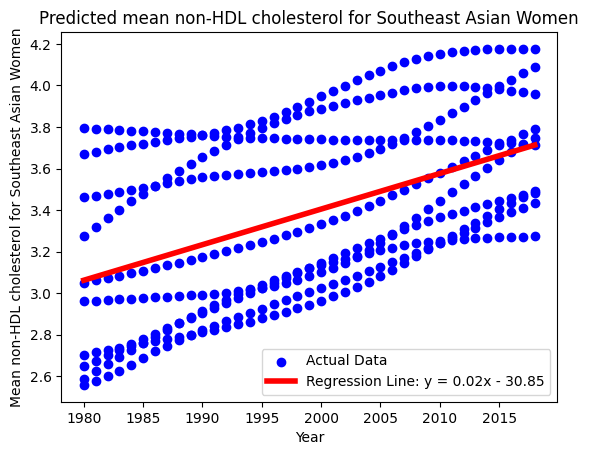

In [185]:
SoutheastAsian_countries = ['Thailand', 'Malaysia', 'Cambodia', 'Viet Nam', 'Lao PDR', 'Brunei Darussalam', 'Philippines', 'Indonesia', 'Myanmar', 'Timor-Leste']
filtered_df = df.loc[df['Country/Region/World'].isin(SoutheastAsian_countries) & (df['Sex'] == 'Women')]
X = filtered_df['Year']
y = filtered_df['Mean non-HDL cholesterol (mmol/L)']

model = LinearRegression()
model.fit(X.values.reshape(-1, 1), y)

print(f"Slope (Coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) # Adjusted X_line range
y_line = model.predict(X_line)
y_pred_2030 = model.predict(np.array([[2030]]))
print(f"Predicted mean non-HDL cholesterol for 2030: {y_pred_2030[0]:.2f}")
y_pred_r2 = model.predict(X.values.reshape(-1, 1))
print(f"R2 Score: {r2_score(y, y_pred_r2):.2f}")

plt.scatter(X, y, color="blue", label="Actual Data")
line_label = f"y = 0.02x - 30.85"
plt.plot(X_line, y_line, color="red", linewidth=4, label= "Regression Line: " + line_label)
plt.title("Predicted mean non-HDL cholesterol for Southeast Asian Women")
plt.xlabel("Year")
plt.ylabel("Mean non-HDL cholesterol for Southeast Asian Women")
plt.legend()
plt.show()

Slope (Coefficient): -0.03
Intercept: 63.18
Predicted mean non-HDL cholesterol for 2030: 2.88
R2 Score: 0.77


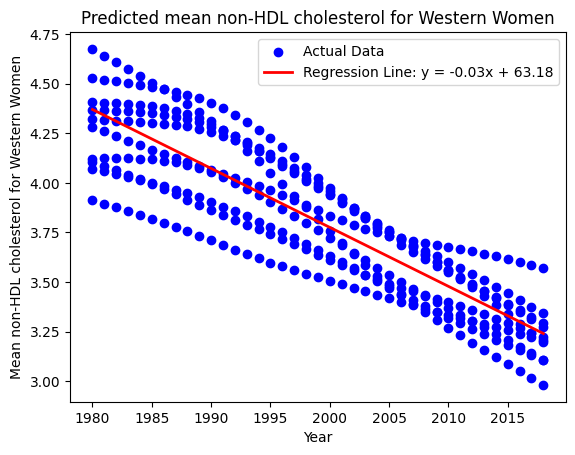

In [186]:

filtered_df = df.loc[df['Country/Region/World'].isin(western_countries) & (df['Sex'] == 'Women')]
X = filtered_df['Year']
y = filtered_df['Mean non-HDL cholesterol (mmol/L)']

model = LinearRegression()
model.fit(X.values.reshape(-1, 1), y)

print(f"Slope (Coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) # Adjusted X_line range
y_line = model.predict(X_line)
y_pred_2030 = model.predict(np.array([[2030]]))
print(f"Predicted mean non-HDL cholesterol for 2030: {y_pred_2030[0]:.2f}")
y_pred_r2 = model.predict(X.values.reshape(-1, 1))
print(f"R2 Score: {r2_score(y, y_pred_r2):.2f}")

plt.scatter(X, y, color="blue", label="Actual Data")
line_label = f"y = -0.03x + 63.18"
plt.plot(X_line, y_line, color="red", linewidth=2, label="Regression Line: " + line_label)
plt.title("Predicted mean non-HDL cholesterol for Western Women")
plt.xlabel("Year")
plt.ylabel("Mean non-HDL cholesterol for Western Women")
plt.legend()
plt.show()